<a href="https://colab.research.google.com/github/NiteshJ98/LLM-from-scratch/blob/main/Layer%201/Phase%203/OverFitting%26Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Overfitting, underfitting, train/val/test splits, learning rate schedules, and regularization**

**Overfitting and underfitting — the core tension**

Every model sits somewhere on a spectrum between two failure modes.

**Underfitting** — the model is too simple to capture the pattern in the data. It performs badly on both training data and new data. The model hasn't learned enough.

**Overfitting** — the model has learned the training data too well, including its noise and quirks. It performs well on training data but badly on new data. The model has memorized instead of generalized


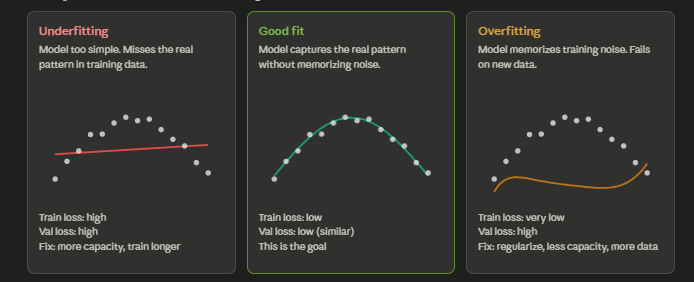

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Generate noisy sine wave data
N = 80
X = torch.linspace(0, 1, N).unsqueeze(1)
y = torch.sin(X * 3.14) + 0.15 * torch.randn(N, 1)

# Three models of different capacity
class TinyNet(nn.Module):      # underfits — too simple
    def __init__(self):
        super().__init__()
        self.net = nn.Linear(1, 1)    # just a line
    def forward(self, x): return self.net(x)

class GoodNet(nn.Module):      # fits well
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1)
        )
    def forward(self, x): return self.net(x)

class HugeNet(nn.Module):      # overfits — too much capacity for this data
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x): return self.net(x)

def train_model(model, X, y, epochs=2000, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []  # List to store loss at each epoch
    for _ in range(epochs):
        opt.zero_grad()
        loss = nn.MSELoss()(model(X), y)
        loss.backward()
        opt.step()
        # Append the scalar value of the loss
        loss_history.append(loss.item())
    return model, loss_history


# Train and collect histories
tiny, tiny_history = train_model(TinyNet(), X, y)
good, good_history = train_model(GoodNet(), X, y)
huge, huge_history = train_model(HugeNet(), X, y)

# Compare predictions
with torch.no_grad():
    Xtest = torch.linspace(0, 1, 200).unsqueeze(1)
    print("Train MSE:")
    print(f"  TinyNet (underfit): {nn.MSELoss()(tiny(X), y).item():.4f}")
    print(f"  GoodNet:            {nn.MSELoss()(good(X), y).item():.4f}")
    print(f"  HugeNet (overfit):  {nn.MSELoss()(huge(X), y).item():.4f}")
    # HugeNet will show near-zero train loss but terrible on new points

Train MSE:
  TinyNet (underfit): 0.1421
  GoodNet:            0.0190
  HugeNet (overfit):  0.0124


In [ ]:
plt.figure(figsize=(10, 6))

# Plot each history
plt.plot(tiny_history, label='TinyNet (Underfit)', color='salmon')
plt.plot(good_history, label='GoodNet (Optimal)', color='skyblue')
plt.plot(huge_history, label='HugeNet (Overfit)', color='plum')

# Formatting
plt.yscale('log') # Use log scale because losses vary by orders of magnitude
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Log Scale)')
plt.title('Training Loss Convergence Across Models')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

In [ ]:
# Switch to evaluation mode and get predictions
with torch.no_grad():
    y_tiny = tiny(X)
    y_good = good(X)
    y_huge = huge(X)

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(15, 14))
fig.suptitle('Model Predictions vs. True Values', fontsize=16)

# Data for plotting
model_data = [
    (y_tiny, 'TinyNet (Underfit)', axes[0, 0], 'salmon'),
    (y_good, 'GoodNet (Optimal)', axes[0, 1], 'skyblue'),
    (y_huge, 'HugeNet (Overfit)', axes[1, 0], 'plum')
]

for pred, title, ax, color in model_data:
    # Plot True Values
    ax.plot(X.numpy(), y.numpy(), label='True Value', color='black', linestyle='--', alpha=0.6)
    # Plot Predicted Values
    ax.plot(X.numpy(), pred.numpy(), label='Predicted', color=color, linewidth=2)

    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('y')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Let's see how this noise looks on the actual function visually.**

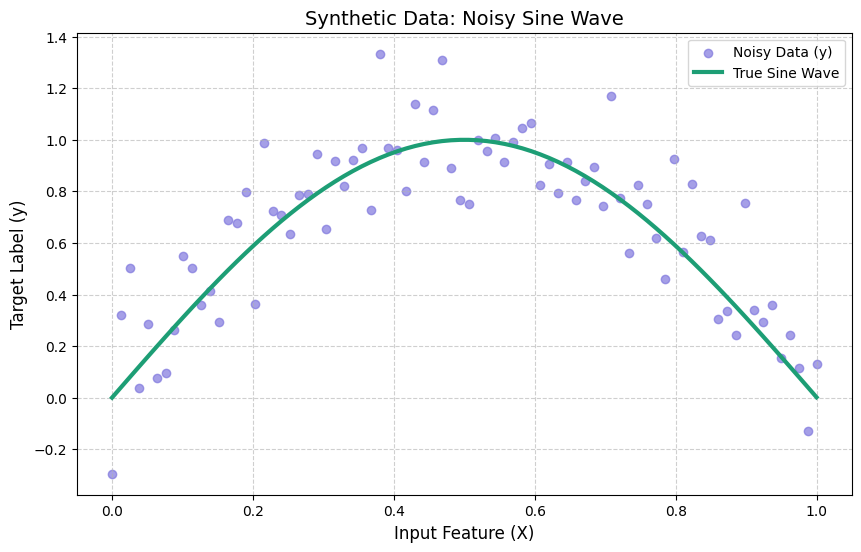

In [ ]:
# 1. Generate the data (Your original code)
N = 80
X = torch.linspace(0, 1, N).unsqueeze(1)
# We separate the "true" signal from the "noise" for better visualization
y_true = torch.sin(X * 3.14)
noise = 0.15 * torch.randn(N, 1)
y = y_true + noise

# 2. Create the visualization
plt.figure(figsize=(10, 6))

# Plot the noisy data points (the data a model would see)
plt.scatter(X.numpy(), y.numpy(), color='#7F77DD', label='Noisy Data (y)', alpha=0.7)

# Plot the underlying sine wave (the "ground truth" the model tries to learn)
plt.plot(X.numpy(), y_true.numpy(), color='#1D9E75', linewidth=3, label='True Sine Wave')

# Add styling and labels
plt.title('Synthetic Data: Noisy Sine Wave', fontsize=14)
plt.xlabel('Input Feature (X)', fontsize=12)
plt.ylabel('Target Label (y)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Train / Val / Test splits — the diagnostic tool**

The split is how you detect overfitting. Without it, you have no way to know if your model is generalizing or memorizing.

**Training set** — what the model learns from. Gradients are computed on this.

**Validation set** — held out during training. You check loss here after every epoch. This is your early warning system for overfitting.

**Test set** — touched exactly once, at the very end. This gives your honest estimate of real-world performance. If you use it more than once to make decisions, you've leaked information and it's no longer honest.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

torch.manual_seed(42)

# Full dataset
N = 1000
X = torch.randn(N, 8)
y = (X[:, 0] + X[:, 1] * 0.5 - X[:, 2] + 0.3 * torch.randn(N)).unsqueeze(1)

dataset = TensorDataset(X, y)

# Split: 70% train, 15% val, 15% test
n_train = int(0.70 * N)    # 700
n_val   = int(0.15 * N)    # 150
n_test  = N - n_train - n_val  # 150

train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
test_loader  = DataLoader(test_ds,  batch_size=32)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# Training loop that tracks both train and val loss
model   = nn.Sequential(nn.Linear(8,64), nn.ReLU(), nn.Linear(64,32), nn.ReLU(), nn.Linear(32,1))
opt     = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

train_losses, val_losses = [], []

for epoch in range(100):
    # ── Train ──
    model.train()
    batch_losses = []
    for Xb, yb in train_loader:
        opt.zero_grad()
        loss = loss_fn(model(Xb), yb)
        loss.backward()
        opt.step()
        batch_losses.append(loss.item())
    train_losses.append(sum(batch_losses) / len(batch_losses))

    # ── Validate ──
    model.eval()
    with torch.no_grad():
        val_loss = sum(loss_fn(model(Xb), yb).item() for Xb, yb in val_loader)
        val_losses.append(val_loss / len(val_loader))

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | train={train_losses[-1]:.4f} | val={val_losses[-1]:.4f}")

# ── Final honest test evaluation — done ONCE at the end ──
model.eval()
with torch.no_grad():
    test_loss = sum(loss_fn(model(Xb), yb).item() for Xb, yb in test_loader)
    test_loss /= len(test_loader)
print(f"\nFinal test loss: {test_loss:.4f}")

# Plot the diagnostic curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train', color='#534AB7')
plt.plot(val_losses,   label='Val',   color='#E24B4A', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Train vs Val loss — watch for the gap')
plt.legend(); plt.tight_layout(); plt.show()

**Reading the diagnostic curve**: if train loss keeps falling but val loss stops falling (or rises), that's overfitting starting. The point where they diverge is when you should stop training.

**Regularization — techniques to fight overfitting**

Regularization is essentially the "discipline" you apply to a neural network to prevent it from overfitting.

When a model overfits, it stops learning the general patterns (the "signal") and starts memorizing the specific random noise in your training data. As a result, it performs perfectly on training data but fails miserably on new, unseen data.

Here is the breakdown of the most common regularization techniques in PyTorch.

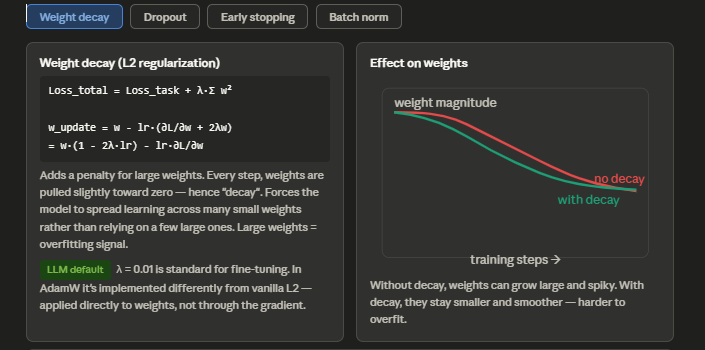

1. **Weight Decay ($L2$ Regularization)**

This is the most common form of regularization. It adds a penalty to the loss function based on the size of the weights.

The Math: $\text{Total Loss} = \text{Loss}_{\text{task}} + \lambda \sum w^2$

The Logic: Large weights often indicate that the model is relying too heavily on a specific feature. By penalizing large weights, we force the model to spread its "knowledge" across many small weights, leading to a smoother, more generalizable function.


**How to do it in PyTorch:**

You don't change your model code; you simply add the weight_decay parameter to your optimizer.


```
# lambda (weight_decay) is typically 1e-5 to 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
```



**2. Dropout**

Dropout is a clever technique where, during each training step, you randomly "switch off" (set to zero) a percentage of neurons in a layer.

**The Logic:** This prevents neurons from becoming overly reliant on each other (co-adaptation). Since a neuron can't depend on any specific neighbor being present, it's forced to learn more robust features.

**Important:** Dropout is only active during training. During evaluation, all neurons are used.

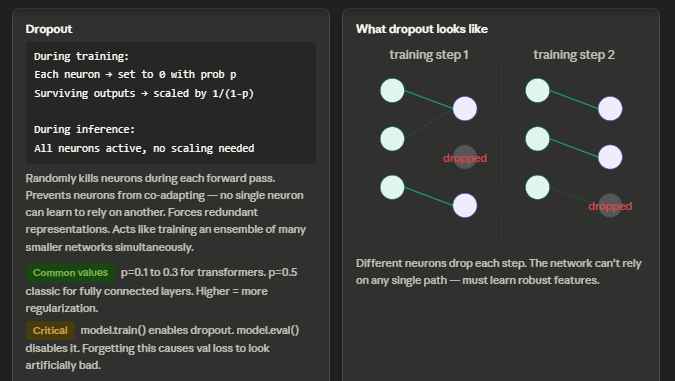




**How to do it in PyTorch:**
```
class RegularizedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 50)
        self.dropout = nn.Dropout(p=0.5) # 50% chance to drop a neuron
        self.fc2 = nn.Linear(50, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x) # Apply dropout after activation
        x = self.fc2(x)
        return x
```





3. **Early Stopping**

Early stopping isn't a line of math, but a training strategy. You monitor the Validation Loss. When the training loss keeps going down but the validation loss starts going up, the model has begun to overfit. You stop training right there.

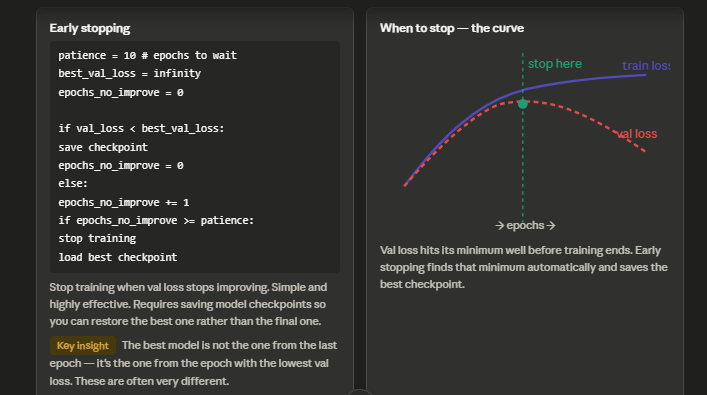

4. **Batch Normalization**

While often used to speed up training, Batch Norm also has a slight regularizing effect. It normalizes the inputs to each layer to have a mean of 0 and a variance of 1 for each mini-batch.

**The Logic:** Because the mean and variance are calculated on small batches, they add a small amount of "noise" to the activations, which acts as a form of regularization.

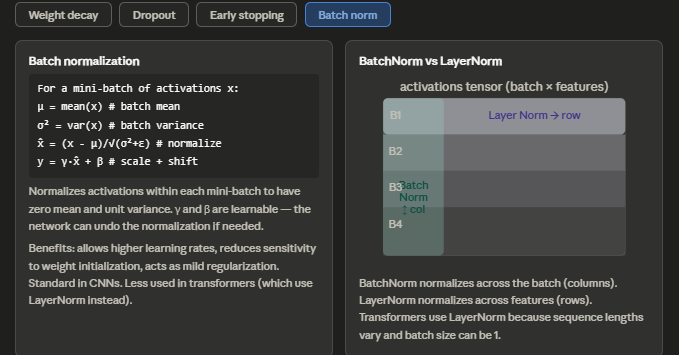

**How to do it in PyTorch:**
```
self.bn1 = nn.BatchNorm1d(50) # '50' is the number of features/neurons
# In forward():
# x = self.fc1(x)
# x = self.bn1(x)
# x = torch.relu(x)
```

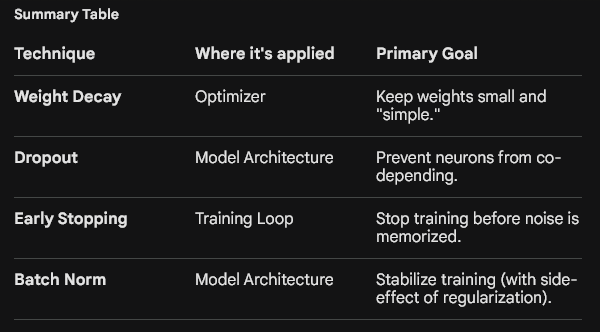


In [ ]:
import torch
import torch.nn as nn

# Weight decay — pass to optimizer, not model
model = nn.Sequential(nn.Linear(8, 64), nn.ReLU(), nn.Linear(64, 1))

# AdamW = Adam + correct weight decay (use this, not Adam + weight_decay)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
# weight_decay=0.01 means: each step, weights are multiplied by (1 - 0.01*lr)
# before the gradient update. Keeps weights small.

# Dropout — add directly in model definition
class RegularizedNet(nn.Module):
    def __init__(self, dropout_p=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),   # kills 20% of neurons during training
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

model = RegularizedNet(dropout_p=0.2)

# Critical: dropout behavior changes between train and eval
model.train()
out_train = model(torch.randn(4, 8))   # some neurons zeroed

model.eval()
out_eval = model(torch.randn(4, 8))    # all neurons active
# Always use model.eval() + torch.no_grad() for validation and inference

# Early stopping — implement as a class
class EarlyStopper:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = float('inf')
        self.counter    = 0

    def should_stop(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
            return False         # improved — keep training
        self.counter += 1
        return self.counter >= self.patience   # no improvement — stop

stopper = EarlyStopper(patience=10)

for epoch in range(1000):
    # ... train ...
    val_loss = 0.5   # placeholder

    if stopper.should_stop(val_loss):
        print(f"Early stop at epoch {epoch}")
        break

# Save and restore best checkpoint
best_loss = float('inf')

for epoch in range(100):
    # ... train ...
    val_loss = 0.3  # placeholder

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')  # save best

# After training: restore best weights (not final weights!)
model.load_state_dict(torch.load('best_model.pth'))

**Learning rate schedules**

The learning rate is the most sensitive hyperparameter. Too high: training explodes. Too low: training stalls. A schedule changes the learning rate during training — high early when you need to move fast, low later when you're fine-tuning near a minimum.

In [ ]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    LinearLR,
    SequentialLR,
    ReduceLROnPlateau,
    OneCycleLR
)
import matplotlib.pyplot as plt

model = nn.Linear(8, 1)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-3)

# ── 1. Step decay — halve LR every 30 epochs ──────────────────
scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=30, gamma=0.5)

# ── 2. Cosine annealing — smooth decay to near zero ───────────
scheduler = CosineAnnealingLR(opt, T_max=100, eta_min=1e-6)

# ── 3. Warmup + cosine — the LLM fine-tuning standard ─────────
warmup = LinearLR(opt, start_factor=0.1, end_factor=1.0, total_iters=10)
cosine = CosineAnnealingLR(opt, T_max=90, eta_min=1e-6)
scheduler = SequentialLR(opt, schedulers=[warmup, cosine], milestones=[10])
# LR ramps from 1e-4 to 1e-3 over 10 steps, then cosine decays to 1e-6

# ── 4. Reduce on plateau — reactive, good for unknowns ────────
scheduler = ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
# Usage: scheduler.step(val_loss)  — reduces LR if val_loss stops improving

# ── 5. OneCycleLR — fast training in one cycle ────────────────
scheduler = OneCycleLR(opt, max_lr=1e-3, total_steps=100)

# Visualize warmup + cosine (most important for fine-tuning)
opt2 = torch.optim.AdamW(nn.Linear(8,1).parameters(), lr=1e-3)
w2   = LinearLR(opt2, start_factor=0.1, end_factor=1.0, total_iters=10)
c2   = CosineAnnealingLR(opt2, T_max=90, eta_min=1e-6)
s2   = SequentialLR(opt2, schedulers=[w2, c2], milestones=[10])

lrs = []
for step in range(100):
    opt2.step()     # dummy step
    s2.step()
    lrs.append(opt2.param_groups[0]['lr'])

plt.figure(figsize=(8, 3))
plt.plot(lrs, color='#534AB7', linewidth=2)
plt.axvline(10, color='#E24B4A', linestyle='--', alpha=0.5, label='warmup ends')
plt.xlabel('Step'); plt.ylabel('Learning rate')
plt.title('Warmup (10 steps) → cosine decay — standard LLM fine-tuning schedule')
plt.legend(); plt.tight_layout(); plt.show()

**Why warmup?** At the very start of training, weights are random or from a pre-trained checkpoint that hasn't seen your data. Gradients are large and noisy. Jumping straight to full learning rate causes destructive updates. Warmup lets the model take small careful steps first, then accelerates once gradients stabilize.

**Why cosine decay?** Near the end of training, the model is close to a good minimum. Large steps overshoot it. Cosine decay shrinks steps gradually, allowing the model to settle precisely.

**Putting it all together — a fully regularized training loop**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR

torch.manual_seed(42)

# Data
N = 800
X = torch.randn(N, 16)
y = (X[:, :4].sum(dim=1, keepdim=True) + 0.5*torch.randn(N, 1))

# Split
ds = TensorDataset(X, y)
tr, va, te = random_split(ds, [600, 100, 100])
train_dl = DataLoader(tr, batch_size=32, shuffle=True)
val_dl   = DataLoader(va, batch_size=32)
test_dl  = DataLoader(te, batch_size=32)

# Model with dropout
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(16, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)

model   = Net()
loss_fn = nn.MSELoss()

# AdamW with weight decay
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

# Warmup + cosine schedule
EPOCHS      = 100
WARMUP_STEPS = 10
warmup   = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_STEPS)
cosine   = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_STEPS, eta_min=1e-6)
schedule = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_STEPS])

# Early stopping
stopper    = EarlyStopper(patience=15)
best_loss  = float('inf')
train_hist, val_hist = [], []

for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────
    model.train()
    tl = []
    for Xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model(Xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # ↑ gradient clipping — prevents exploding gradients,
        #   rescales gradients if their norm exceeds 1.0
        optimizer.step()
        tl.append(loss.item())
    schedule.step()

    # ── Validate ───────────────────────────────────────
    model.eval()
    with torch.no_grad():
        vl = sum(loss_fn(model(Xb), yb).item() for Xb, yb in val_dl)
        vl /= len(val_dl)

    train_hist.append(sum(tl)/len(tl))
    val_hist.append(vl)

    if vl < best_loss:
        best_loss = vl
        torch.save(model.state_dict(), 'best.pth')

    if stopper.should_stop(vl):
        print(f"Early stop at epoch {epoch+1}")
        break

    if epoch % 20 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | train={train_hist[-1]:.4f} | "
              f"val={val_hist[-1]:.4f} | lr={lr_now:.6f}")

# ── Final evaluation ───────────────────────────────────
model.load_state_dict(torch.load('best.pth'))   # restore best, not last
model.eval()
with torch.no_grad():
    test_loss = sum(loss_fn(model(Xb), yb).item() for Xb, yb in test_dl)
    print(f"\nTest loss (best checkpoint): {test_loss/len(test_dl):.4f}")

**Diagnosing what's wrong — the decision tree**

Train loss high + Val loss high  →  Underfitting
```
Fix: bigger model, train longer,
    lower learning rate,check data pipeline isn't broken
```

Train loss low + Val loss high   →  Overfitting

```
 `Fix: add dropout, weight decay,  
   early stopping, get more data, reduce model size`
```



Train loss not moving            →  Learning rate too low

    `Fix: increase lr by 10x, check optimizer.zero_grad()`

Train loss exploding (NaN/inf)   →  Learning rate too high

    `Fix: reduce lr by 10x, add gradient clipping`

Val loss lower than train loss   →  Dropout is on during val

    `Fix: model.eval() before validation — always`

Train and val loss identical     →  Val set leaking into train

    `Fix: check your data split — shuffle before splitting`

**For LLM fine-tuning specifically:** Overfitting is the main enemy because you have a very large model and often a small dataset. The combination of AdamW + weight decay + warmup + cosine + early stopping is the standard recipe because it handles all the failure modes at once.